In [ ]:
!pip install pandas numpy scikit-learn
!pip install transformers sentence-transformers
!pip install torch matplotlib

In [ ]:
import numpy as np # linier algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib
import matplotlib.pyplot as plt
%matplotlib inline

sns.set_style("darkgrid")
matplotlib.rcParams['font.size'] = 14
matplotlib.rcParams['figure.figsize'] = (9, 5)
matplotlib.rcParams['figure.facecolor'] = '#00000000'

In [ ]:
df=pd.read_csv("/content/drive/MyDrive/Sistem Rekomendasi/indian_food.csv")
df.sample(10)

,name,ingredients,diet,prep_time,cook_time,flavor_profile,course,state,region
41,Double ka meetha,"Loaf bread, milk",vegetarian,20,30,sweet,dessert,Telangana,South
149,Payasam,"Rice, cashew nuts, milk, raisins, sugar",vegetarian,15,30,sweet,dessert,-1,South
80,Chicken Tikka masala,"Naan bread, tomato sauce, skinless chicken bre...",non vegetarian,10,50,spicy,main course,Punjab,North
21,Chhena kheeri,"Chhena, sugar, milk",vegetarian,-1,60,sweet,dessert,Odisha,East
86,Dal tadka,"Pigeon peas, garam masala, ginger, red onion, ...",vegetarian,10,30,spicy,main course,Punjab,North
231,Brown Rice,"Brown rice, soy sauce, olive oil",vegetarian,15,25,-1,main course,-1,-1
127,Currivepillai sadam,"Chana dal, urad dal, fresh coconut, sesame see...",vegetarian,10,20,spicy,main course,Tamil Nadu,South
251,Bebinca,"Coconut milk, egg yolks, clarified butter, all...",vegetarian,20,60,sweet,dessert,Goa,West
97,Lauki ke kofte,"Bottle gourd, garam masala powder, gram flour,...",vegetarian,20,40,spicy,main course,Uttar Pradesh,North
148,Paravannam,"Raw rice, jaggery, milk",vegetarian,-1,-1,spicy,main course,Kerala,South


In [ ]:
df.describe()

,prep_time,cook_time
count,255.000000,255.000000
mean,31.105882,34.529412
std,72.554409,48.265650
min,-1.000000,-1.000000
25%,10.000000,20.000000
50%,10.000000,30.000000
75%,20.000000,40.000000
max,500.000000,720.000000


In [ ]:
df['state'].unique()

array(['West Bengal', 'Rajasthan', 'Punjab', 'Uttar Pradesh', '-1',
       'Odisha', 'Maharashtra', 'Uttarakhand', 'Assam', 'Bihar',
       'Andhra Pradesh', 'Karnataka', 'Telangana', 'Kerala', 'Tamil Nadu',
       'Gujarat', 'Tripura', 'Manipur', 'Nagaland', 'NCT of Delhi',
       'Jammu & Kashmir', 'Chhattisgarh', 'Haryana', 'Madhya Pradesh',
       'Goa'], dtype=object)

In [ ]:
df['region'].unique()

array(['East', 'West', 'North', '-1', 'North East', 'South', 'Central',
       nan], dtype=object)

In [ ]:
df['flavor_profile'].unique()

array(['sweet', 'spicy', 'bitter', '-1', 'sour'], dtype=object)

In [ ]:
df[df['state']=='-1']

,name,ingredients,diet,prep_time,cook_time,flavor_profile,course,state,region
7,Kaju katli,"Cashews, ghee, cardamom, sugar",vegetarian,10,20,sweet,dessert,-1,-1
9,Kheer,"Milk, rice, sugar, dried fruits",vegetarian,10,40,sweet,dessert,-1,-1
10,Laddu,"Gram flour, ghee, sugar",vegetarian,10,40,sweet,dessert,-1,-1
12,Nankhatai,"Refined flour, besan, ghee, powdered sugar, yo...",vegetarian,20,30,sweet,dessert,-1,-1
94,Khichdi,"Moong dal, green peas, ginger, tomato, green c...",vegetarian,40,20,spicy,main course,-1,-1
96,Kulfi falooda,"Rose syrup, falooda sev, mixed nuts, saffron, ...",vegetarian,45,25,sweet,dessert,-1,-1
98,Lauki ki subji,"Bottle gourd, coconut oil, garam masala, ginge...",vegetarian,10,20,spicy,main course,-1,-1
109,Pani puri,"Kala chana, mashed potato, boondi, sev, lemon",vegetarian,15,2,spicy,snack,-1,-1
111,Papad,"Urad dal, sev, lemon juice, chopped tomatoes",vegetarian,5,5,spicy,snack,-1,-1
115,Rajma chaval,"Red kidney beans, garam masala powder, ginger,...",vegetarian,15,90,spicy,main course,-1,North


In [ ]:
#impute the missing values for state and region

df.iloc[[7,94,100,115],[7,8]] = ['Delhi','North']
df.iloc[[9,117],[7,8]] = ['Uttar Pradesh','North']
df.iloc[[10,96,145,149,154,158,164],[7,8]] =['Andhra Pradesh', 'South']
df.iloc[[12,98],[7,8]] = ['Gujarat','West']
df.iloc[[111,128,130,144,156,161,162,231,248],[7,8]] = ['Tamil Nadu','South']

##Replace the nan for Region
df["region"]=df["region"].fillna(df["region"].mode()[0])

##Replace "-1" for flavor_profile with 'unique' word
df['flavor_profile'].replace(-1, 'unique', regex=True , inplace=True)

##Replace perp_time and cook_time with respective median values
df['prep_time'].replace(-1, df['prep_time'].median(), regex=True, inplace=True)
df['cook_time'].replace(-1, df['cook_time'].median(), regex=True, inplace=True)

/tmp/ipykernel_5316/3649910922.py:13: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['flavor_profile'].replace(-1, 'unique', regex=True , inplace=True)
/tmp/ipykernel_5316/3649910922.py:16: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(valu

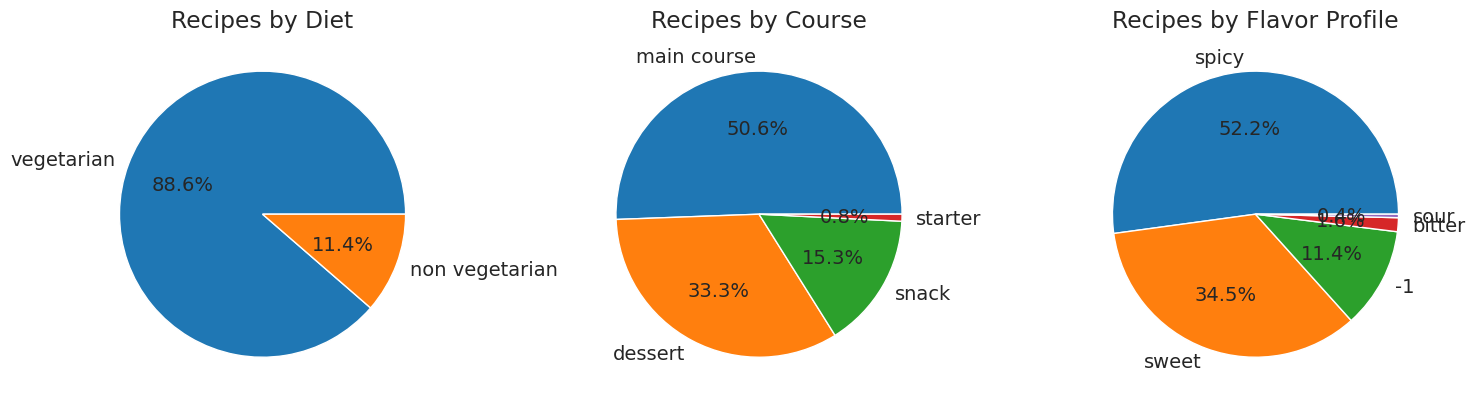

In [ ]:
# Basic EDA & Visualizations

df_diet = df['diet'].value_counts().reset_index()
df_course = df['course'].value_counts().reset_index()
df_flavor = df['flavor_profile'].value_counts().reset_index()

plt.figure(figsize=(15,8))

# Diet
plt.subplot(1,3,1)
plt.pie(df_diet['count'], labels=df_diet['diet'], autopct='%1.1f%%')
plt.title('Recipes by Diet')

# Course
plt.subplot(1,3,2)
plt.pie(df_course['count'], labels=df_course['course'], autopct='%1.1f%%')
plt.title('Recipes by Course')

# Flavor Profile
plt.subplot(1,3,3)
plt.pie(df_flavor['count'], labels=df_flavor['flavor_profile'], autopct='%1.1f%%')
plt.title('Recipes by Flavor Profile')

plt.tight_layout()
plt.show()

In [ ]:
from sentence_transformers import SentenceTransformer

bert = SentenceTransformer("bert-base-nli-mean-tokens")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/3.77k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/2.00 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [ ]:
def get_index(recipe):
    result = df[df['name'] == recipe]

    if result.empty:
        return None

    return result.index[0]


def get_recipe(index):
    if index not in df.index:
        return None

    return df.loc[index, 'name']

In [ ]:
sentence_embeddings = bert.encode(df['ingredients'].tolist())

In [ ]:
from sklearn.metrics.pairwise import cosine_similarity
similarity = cosine_similarity(sentence_embeddings)

In [ ]:
def getRecipeRecommendation(recipe_name):
  return sorted(list(enumerate(similarity[get_index(recipe_name)])), key=lambda x: x[1], reverse=True)

In [ ]:
reccomendations = getRecipeRecommendation('Kheer')
for x in range(10):
  print(get_recipe(reccomendations[x][0]), sep = "\n")

Kheer
Doodhpak
Chak Hao Kheer
Payasam
Phirni
Palathalikalu
Basundi
Rabri
Coconut vadi
Pootharekulu


In [ ]:
reccomendations = getRecipeRecommendation('Dosa')
for x in range(10):
  print(get_recipe(reccomendations[x][0]), sep = "\n")

Dosa
Idli
Kothamali sadam
Gavvalu
Anarsa
Kombdi vade
Ariselu
Idiappam
Fara
Kajjikaya


In [ ]:
reccomendations = getRecipeRecommendation('Tandoori Fish Tikka')
for x in range(10):
  print(get_recipe(reccomendations[x][0]), sep = "\n")

Tandoori Fish Tikka
Gatta curry
Paneer tikka masala
Kadai paneer
Paniyaram
Tandoori Chicken
Butter chicken
Daal puri
Dal tadka
Bombil fry
